# Visualization of single cell RNA-seq

In this part, we will introduce the tutorial of special plot of `omicverse`.

In [1]:
import omicverse as ov
ov.style(font_path='Arial')

# Enable auto-reload for development
%load_ext autoreload
%autoreload 2

/Users/fernandozeng/miniforge3/envs/scanpy/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/4m/2xw3_2s503s9r616083n7w440000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.10rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



We utilized single-cell RNA-seq data (GEO accession: GSE95753) obtained from the dentate gyrus of the hippocampus in mouse.

In [2]:
#import scvelo as scv
#adata = scv.datasets.dentategyrus()
#adata = scv.datasets.dentategyrus()
adata = ov.datasets.dentate_gyrus_scvelo()
adata

Using Stanford mirror for dentategyrus_scv
⚠️ File ./data/dentategyrus_scv.h5ad already exists
 Loading data from ./data/dentategyrus_scv.h5ad
✅ Successfully loaded: 2930 cells × 13913 genes


AnnData object with n_obs × n_vars = 2930 × 13913
    obs: 'clusters', 'age(days)', 'clusters_enlarged'
    uns: 'clusters_colors'
    obsm: 'X_umap'
    layers: 'ambiguous', 'spliced', 'unspliced'

## Optimizing color mapping

Visualizing spatially resolved biological data with appropriate color mapping can significantly facilitate the exploration of underlying patterns and heterogeneity. Spaco (spatial colorization) provides a spatially constrained approach that generates discriminate color assignments for visualizing single-cell spatial data in various scenarios.

Jing Z, Zhu Q, Li L, Xie Y, Wu X, Fang Q, et al. [Spaco: A comprehensive tool for coloring spatial data at single-cell resolution.](https://doi.org/10.1016/j.patter.2023.100915) Patterns. 2024;100915


**Function**: `ov.pl.optim_palette`: 
- adata: the datasets of scRNA-seq
- basis: he position on the plane should be set to `X_spatial` in spatial RNA-seq, `X_umap`,`X_tsne`,`X_mde` in scRNA-seq and should not be set to `X_pca`
- colors: Specify the colour to be optimised, which should be for one of the columns in adata.obs, noting that it should have the colour first, and that we can use ov.pl.embedding to colour the cell types. If there is no colour then colour blind optimisation colour will be used.
- palette: You can also re-specify the colour bar that needs to be drawn, just set `palette=['#FFFFFF','#000000']`, we have prepared `ov.pl.red_color`,`ov.pl.blue_color`,`ov.pl.green_color`,`ov.pl.orange_color`, by default.

In [3]:
#optim_palette=ov.pl.optim_palette(adata,basis='X_umap',colors='clusters')

Text(0.5, 1.0, 'Cell Type of DentateGyrus')

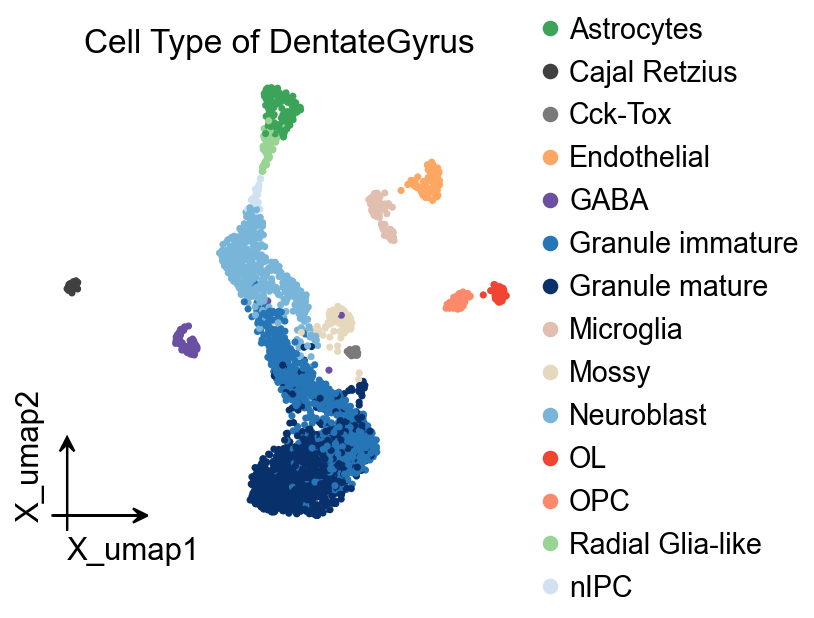

In [12]:
fig,ax=ov.plt.subplots(figsize = (4,4))
ov.pl.embedding(
    adata,
    basis='X_umap',
    color='clusters',
    frameon='small',
    show=False,
    #palette=optim_palette,
    ax=ax,
)
ov.plt.title('Cell Type of DentateGyrus',fontsize=15)

<Axes: title={'center': 'age(days)'}, xlabel='X_umap1', ylabel='X_umap2'>

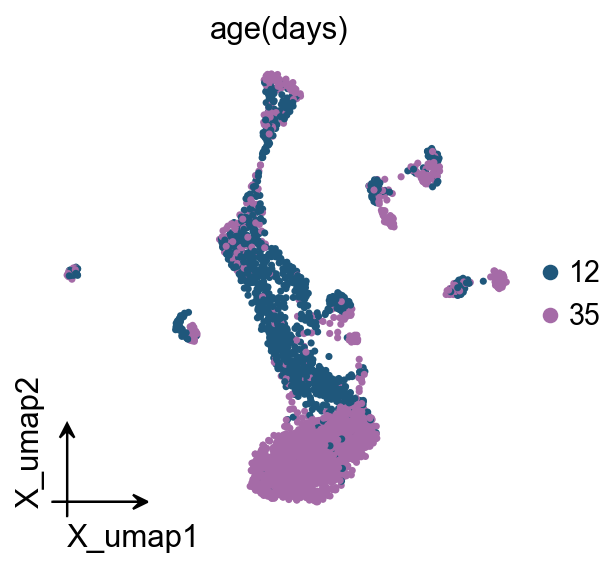

In [13]:
ov.pl.embedding(
    adata,
    basis='X_umap',
    color='age(days)',
    frameon='small',
    show=False,
)

## Stacked histogram of cell proportions

This is a graph that appears widely in various CNS-level journals, and is limited to the fact that `scanpy` does not have a proper way of plotting it, and we provide `ov.pl.cellproportion` for plotting it here.

**Function**: `ov.pl.cellproportion`: 
- adata: the datasets of scRNA-seq
- celltype_clusters: Specify the colour to plot, which should be for one of the columns in adata.obs, noting that it should have the colour first, and that we can use ov.pl.embedding to colour the cell types. If there is no colour then colour blind optimisation colour will be used.
- groupby: The group variable for the different groups of cell types we need to display, in this case we are displaying different ages, so we set it to `age(days)`
- groupby_li: If there are too many groups, we can also select the ones we are interested in plotting, here we use groupby_li to plot the groups
- figsize: If we specify axes, then this variable can be left empty
- legend: Whether to show a legend

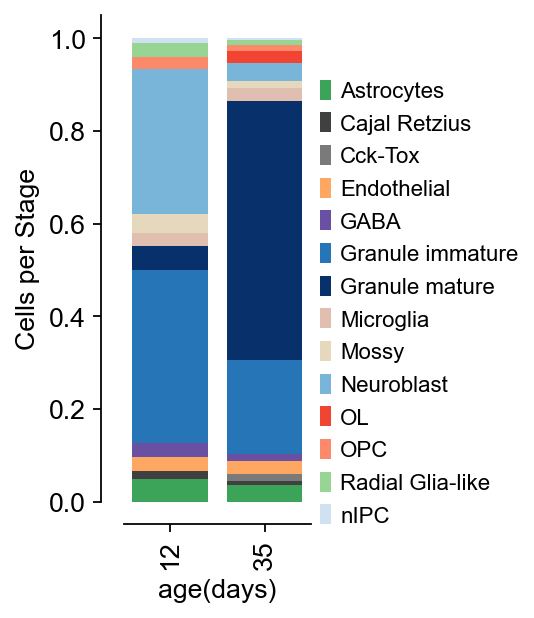

In [14]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize = (1.5,4))
ov.pl.cellproportion(adata=adata,celltype_clusters='clusters',
                    groupby='age(days)',legend=True,ax=ax)

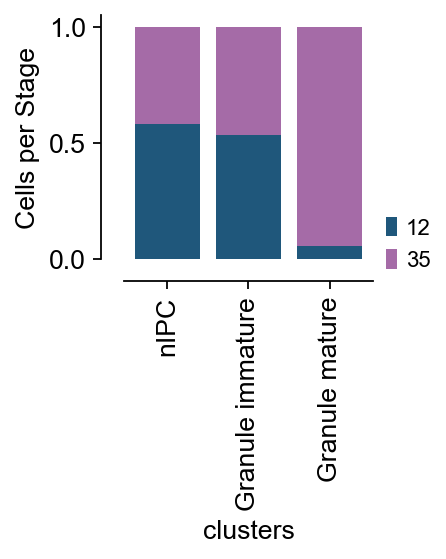

In [15]:
fig,ax=plt.subplots(figsize = (2,2))
ov.pl.cellproportion(adata=adata,celltype_clusters='age(days)',
                    groupby='clusters',groupby_li=['nIPC','Granule immature','Granule mature'],
                     legend=True,ax=ax)

If you are interested in the changes in cell types in different groups, we recommend using a stacked area graph.

age(days)_colors


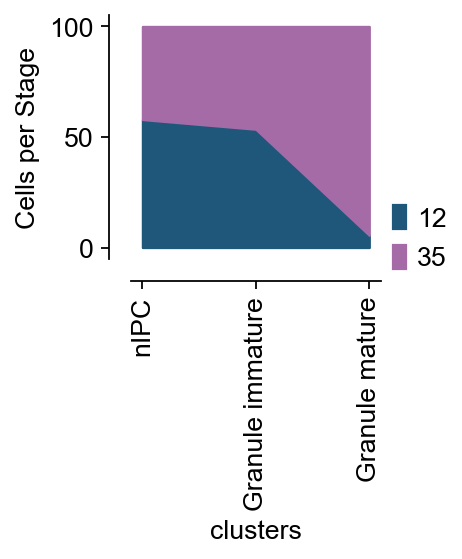

In [16]:
fig,ax=plt.subplots(figsize = (2,2))
ov.pl.cellstackarea(adata=adata,celltype_clusters='age(days)',
                    groupby='clusters',groupby_li=['nIPC','Granule immature','Granule mature'],
                     legend=True,ax=ax,legend_awargs={})

## A collection of some interesting embedded plot

Our first presentation is an embedding map with the number and proportion of cell types. This graph visualises the low-dimensional representation of cells in addition to the number of cell proportions, etc. It should be noted that the cell proportions plotted on the left side may be distorted when there are too many cell types, and we would be grateful if anyone would be interested in fixing this bug.

**Function**: `ov.pl.embedding_celltype`: 
- adata: the datasets of scRNA-seq
- figsize: Note that we don't usually provide the ax parameter for combinatorial graphs, this is due to the fact that combinatorial graphs are made up of multiple axes, so the figsize parameter is more important, here we set it to `figsize=(7,4)`.
- basis: he position on the plane should be set to `X_spatial` in spatial RNA-seq, `X_umap`,`X_tsne`,`X_mde` in scRNA-seq and should not be set to `X_pca`
- celltype_key: Specify the colour to be optimised, which should be for one of the columns in adata.obs, noting that it should have the colour first, and that we can use ov.pl.embedding to colour the cell types. If there is no colour then colour blind optimisation colour will be used.
- title: Note that the space entered in title is used to control the position.
- celltype_range: Since our number of cell types is different in each data, we want to have the flexibility to control where the cell scale plot is drawn, here we set it to `(1,10)`. You can also tweak the observations yourself to find the parameter that best suits your data.
- embedding_range: As with the positional parameters of the cell types, they need to be adjusted several times on their own for optimal results.

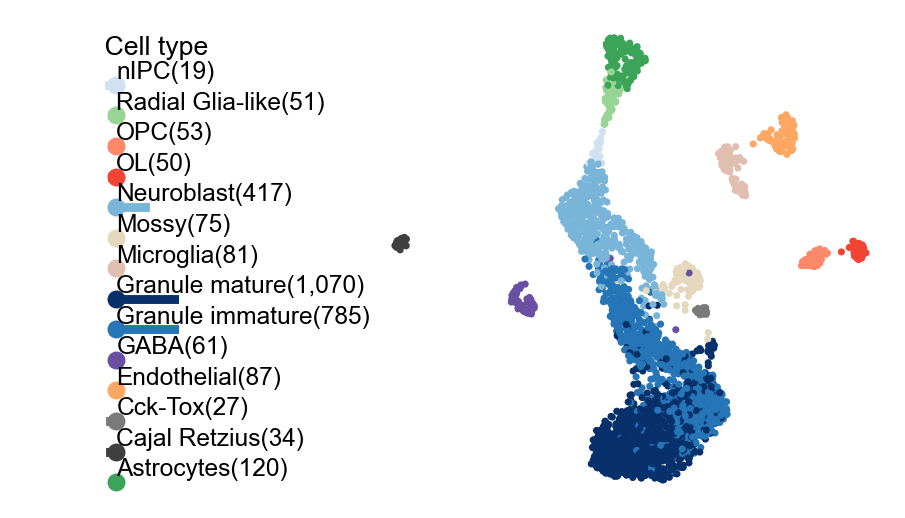

In [17]:
fig,(ax1,ax2)=ov.pl.embedding_celltype(
    adata,figsize=(7,4),basis='X_umap',
    celltype_key='clusters',
    title='            Cell type',
    celltype_range=(1,10),
    embedding_range=(4,10),
)

Sometimes we want to be able to circle a certain type of cell that we are interested in, and here we use convex polygons to achieve this, while the shape of the convex polygons may be optimised in future versions.

**Function**: `ov.pl.ConvexHull`: 
- adata: the datasets of scRNA-seq
- basis: he position on the plane should be set to `X_spatial` in spatial RNA-seq, `X_umap`,`X_tsne`,`X_mde` in scRNA-seq and should not be set to `X_pca`
- cluster_key: Specify the celltype to be optimised, which should be for one of the columns in adata.obs, noting that it should have the colour first, and that we can use ov.pl.embedding to colour the cell types. If there is no colour then colour blind optimisation colour will be used.
- hull_cluster: the target celltype to be circled.

clusters_colors


<Axes: title={'center': 'clusters'}, xlabel='X_umap1', ylabel='X_umap2'>

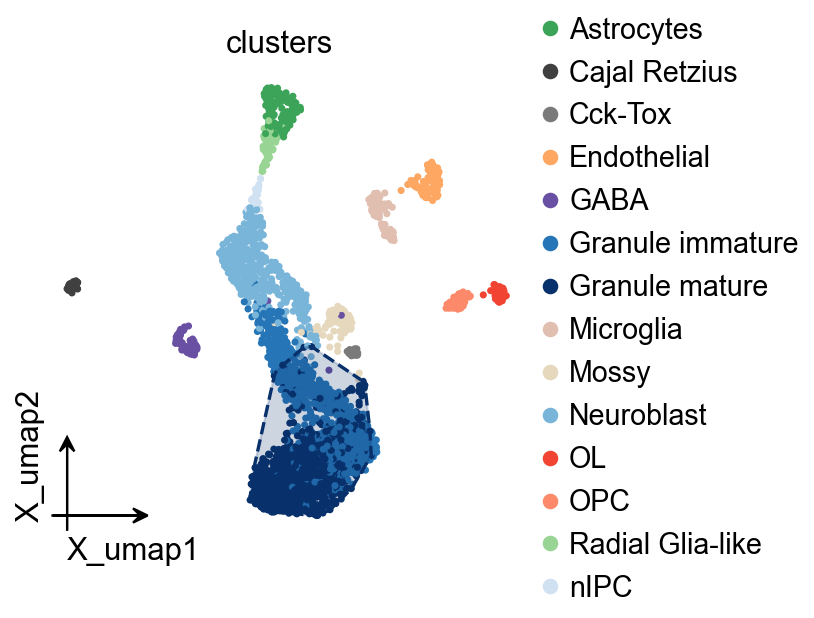

In [18]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize = (4,4))

ov.pl.embedding(adata,
                basis='X_umap',
                color=['clusters'],
                frameon='small',
                show=False,
                ax=ax)

ov.pl.ConvexHull(adata,
                basis='X_umap',
                cluster_key='clusters',
                hull_cluster='Granule mature',
                ax=ax)


Besides, if you don't want to plot convexhull, you can plot the contour instead. 

**Function**: `ov.pl.contour`: 
- adata: the datasets of scRNA-seq
- basis: he position on the plane should be set to `X_spatial` in spatial RNA-seq, `X_umap`,`X_tsne`,`X_mde` in scRNA-seq and should not be set to `X_pca`
- groupby: Specify the celltype to be optimised, which should be for one of the columns in adata.obs, noting that it should have the colour first, and that we can use ov.pl.embedding to colour the cell types. If there is no colour then colour blind optimisation colour will be used.
- clusters: the target celltype to be circled. 
- colors: the color of the contour
- linestyles: the linestyles of the contour
- **kwargs: more kwargs could be found from `plt.contour`

<Axes: title={'center': 'clusters'}, xlabel='X_umap1', ylabel='X_umap2'>

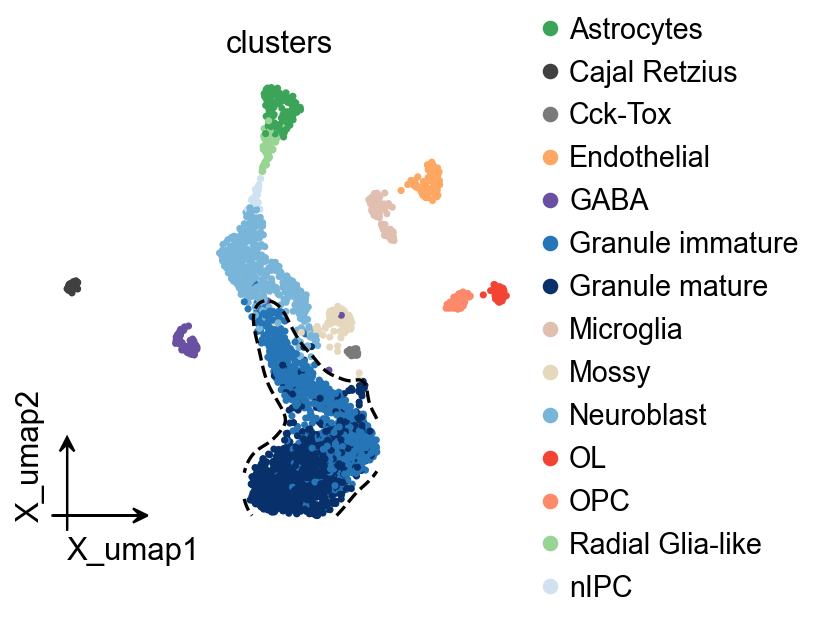

In [19]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize = (4,4))

ov.pl.embedding(adata,
                basis='X_umap',
                color=['clusters'],
                frameon='small',
                show=False,
                ax=ax)

ov.pl.contour(ax=ax,adata=adata,groupby='clusters',clusters=['Granule immature','Granule mature'],
       basis='X_umap',contour_threshold=0.1,colors='#000000',
        linestyles='dashed',)


In scanpy's default `embedding` plotting function, when we set legend=True, legend masking may occur. To solve this problem, we introduced `ov.pl.embedding_adjust` in omicverse to automatically adjust the position of the legend.

**Function**: `ov.pl.embedding_adjust`: 
- adata: the datasets of scRNA-seq
- basis: he position on the plane should be set to `X_spatial` in spatial RNA-seq, `X_umap`,`X_tsne`,`X_mde` in scRNA-seq and should not be set to `X_pca`
- groupby: Specify the celltype to be optimised, which should be for one of the columns in adata.obs, noting that it should have the colour first, and that we can use ov.pl.embedding to colour the cell types. If there is no colour then colour blind optimisation colour will be used.
- exclude: We can specify which cell types are not to be plotted, in this case we set it to `OL`
- adjust_kwargs: We can manually specify the parameters of [adjustText](https://adjusttext.readthedocs.io/en/latest/), the specific parameters see the documentation of adjustText, it should be noted that we have to use dict to specify the parameters here.
- text_kwargs: We can also specify the font colour manually by specifying the [text_kwargs](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.text.html) parameter

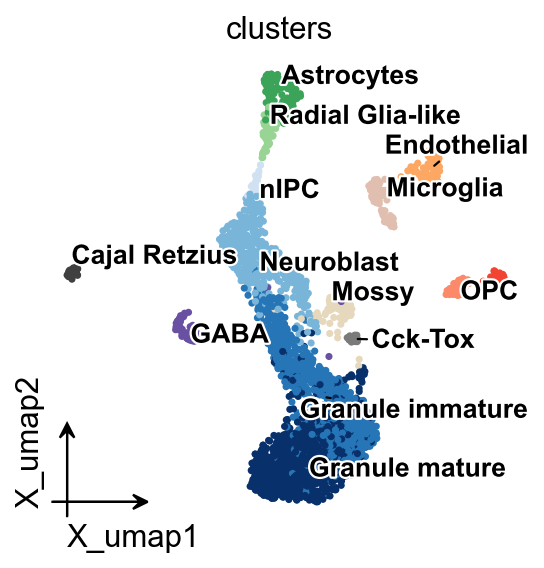

In [21]:
from matplotlib import patheffects
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4,4))

ov.pl.embedding(
    adata,
    basis='X_umap',
    color=['clusters'],
    show=False, legend_loc=None, add_outline=False, 
    frameon='small',legend_fontoutline=2,ax=ax
)

ov.pl.embedding_adjust(
    adata,
    groupby='clusters',
    exclude=("OL",),  
    basis='X_umap',
    ax=ax,
    adjust_kwargs=dict(arrowprops=dict(arrowstyle='-', color='black')),
    text_kwargs=dict(fontsize=12 ,weight='bold',
                     path_effects=[patheffects.withStroke(linewidth=2, foreground='w')] ),
)
ov.plt.show()

Sometimes we are interested in the distribution density of a certain class of cell types in a categorical variable, which is cumbersome to plot in the `scanpy` implementation, so we have simplified the implementation in omicverse and ensured the same plotting.

**Function**: `ov.pl.embedding_density`: 
- adata: the datasets of scRNA-seq
- basis: he position on the plane should be set to `X_spatial` in spatial RNA-seq, `X_umap`,`X_tsne`,`X_mde` in scRNA-seq and should not be set to `X_pca`
- groupby: Specify the celltype to be optimised, which should be for one of the columns in adata.obs, noting that it should have the colour first, and that we can use ov.pl.embedding to colour the cell types. If there is no colour then colour blind optimisation colour will be used.
- target_clusters: We can specify which cell types are to be plotted, in this case we set it to `Granule mature`
- kwargs: other parameter can be found in `scanpy.pl.embedding`

computing density on 'umap'
--> added
    'temp_density', densities (adata.obs)
    'temp_density_params', parameter (adata.uns)


<Axes: title={'center': 'Granule mature'}, xlabel='X_umap1', ylabel='X_umap2'>

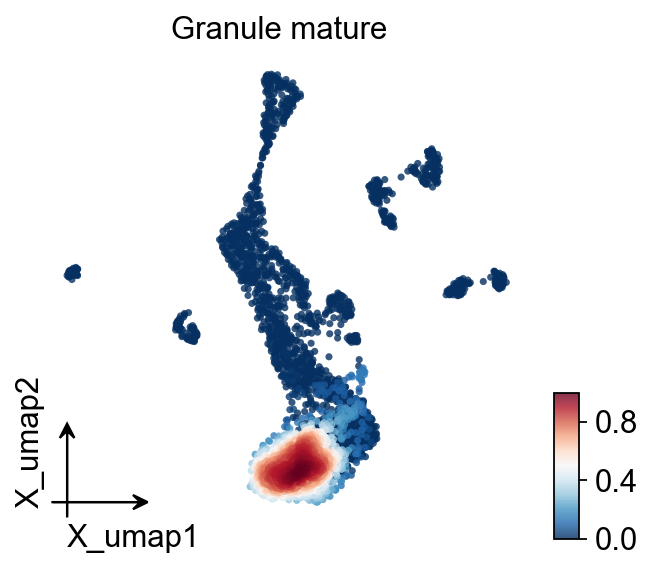

In [22]:
ov.pl.embedding_density(
    adata,
    basis='X_umap',
    groupby='clusters',
    target_clusters='Granule mature',
    frameon='small',
    show=False,cmap='RdBu_r',alpha=0.8
)

## Visualizing Gene Density in Spatial Transcriptomics

Gene density visualization is an essential technique for spatial transcriptomics data analysis. It allows researchers to observe the spatial distribution and expression intensity of specific genes across a tissue section. This approach helps identify regions of high or low expression, spatial gradients, and expression patterns that may correspond to biological structures or functional domains.

Key aspects of gene density visualization:

- **Expression hotspots**: Identify regions where specific genes are highly expressed, which may indicate specialized cell types or functional tissue domains
- **Spatial gradients**: Detect gradual changes in gene expression across tissue that may reflect developmental trajectories or signaling cascades
- **Co-expression patterns**: Analyze the spatial relationship between multiple genes to understand coordinated gene regulation
- **Tissue architecture**: Correlate gene expression with histological features to link molecular profiles with structural elements

Using the `ov.pl.embedding` or `sc.pl.spatial` functions with appropriate parameters allows us to generate these informative visualizations and gain deeper insights into the spatial organization of gene expression within the tissue.

<Axes: title={'center': 'Sox4'}, xlabel='X_umap1', ylabel='X_umap2'>

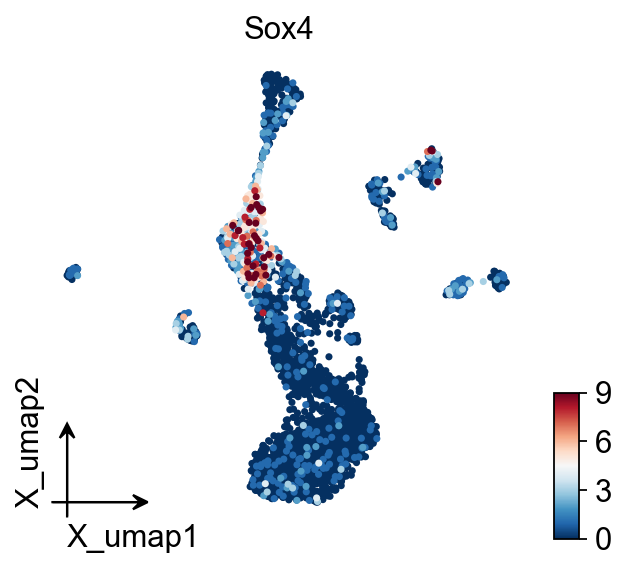

In [23]:
ov.pl.embedding(adata,
                basis='X_umap',
                color=['Sox4'],
                frameon='small',
                vmax='p99.2',
                show=False,)

adjust argument is the most important argument to control the density.

In [24]:
ov.pl.calculate_gene_density(adata,
                              features=['Sox4'],
                              basis='X_umap',
                              dims=(0,1),
                              adjust=0.2,#adjust the bandwidth of the kernel density estimate
                              min_expr=0.01
                              )

✅ density_Sox4 written (train cells = 625)


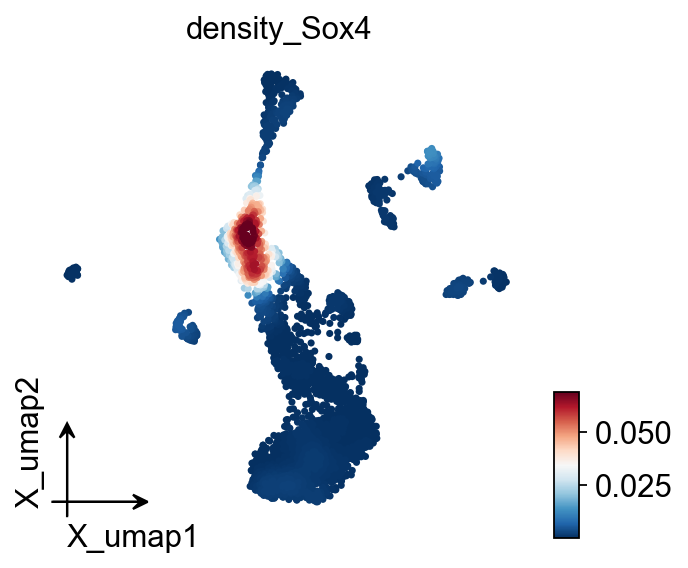

In [25]:
ax=ov.pl.embedding(adata,
                basis='X_umap',
                color=['density_Sox4'],
                frameon='small',
                vmax='p99.2',
                show=False,)

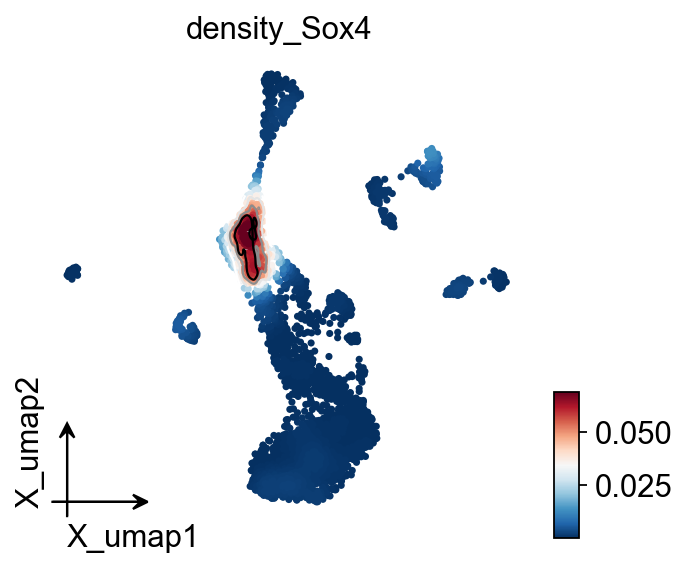

In [26]:

ax=ov.pl.embedding(adata,
                basis='X_umap',
                color=['density_Sox4'],
                frameon='small',
                vmax='p99.2',
                show=False,)



# overlay contours
ov.pl.add_density_contour(
    ax,
    embeddings=adata[adata.obs["density_Sox4"]>0.03].obsm["X_umap"][:, :2],
    weights=adata[adata.obs["density_Sox4"]>0.03].obs["density_Sox4"].to_numpy(),   # raw expression as weight
    levels="quantile",          # use quantile‐based levels (auto)
    n_quantiles=4,              # 4 contours: 20 %, 40 %, 60 %, 80 %
    bw_adjust=0.25,
    fill=False,                 # set True for filled contours
    linewidth=1.0,
    cmap_contour="Greys",
    zorder=10,
)


## Bar graph with overlapping dots (Bar-dot) plot

In biological research, bardotplot plots are the most common class of graphs we use, but unfortunately, there is no direct implementation of plotting functions in either matplotlib, seaborn or scanpy. To compensate for this, we implement bardotplot plotting in omicverse and provide manual addition of p-values (it should be noted that manual addition refers to the manual addition of p-values for model fitting rather than making up p-values yourself).

In [27]:
ov.single.geneset_aucell(adata,
                            geneset_name='Sox',
                            geneset=['Sox17', 'Sox4', 'Sox7', 'Sox18', 'Sox5'])

100%|████████████████████████████████████████████████████████████| 2930/2930 [00:01<00:00, 2031.62it/s]


In [3]:
import omicverse as ov
ov.style(font_path='Arial')

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/4m/2xw3_2s503s9r616083n7w440000gn/T/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available
✅ plot_set complete.



<Axes: xlabel='clusters', ylabel='Sox4'>

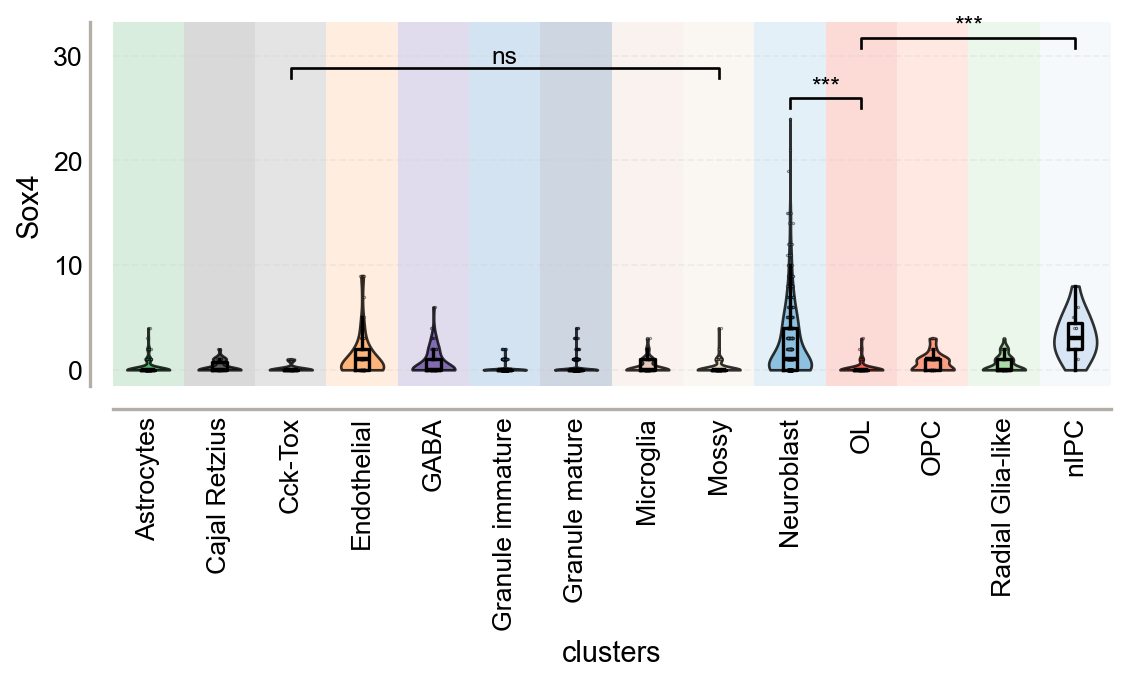

In [14]:
ov.pl.violin(
    adata,keys='Sox4',groupby='clusters',
    figsize=(8,3),rotation=90,
    alternating_background=True,add_box=True,
    use_group_colors_background=True,verbose=False,
    comparisons=[('Neuroblast','OL'),
                ('Mossy','Cck-Tox'),
                ('nIPC','OL')]
    
)

**Function**: `ov.pl.embedding_density`: 
- adata: the datasets of scRNA-seq
- groupby: Specify the celltype to be optimised, which should be for one of the columns in adata.obs, noting that it should have the colour first, and that we can use ov.pl.embedding to colour the cell types. If there is no colour then colour blind optimisation colour will be used.
- color: The size of the variable to be plotted, which can be a gene, stored in adata.var, or a cell value, stored in adata.obs.
- bar_kwargs: We provide the parameters of the barplot for input, see the matplotlib documentation for more [details](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html)
- scatter_kwargs: We also provide the parameters of the scatter for input, see the matplotlib documentation for more [details](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)

**Function**: `ov.pl.add_palue`: 
- ax: the axes of bardotplot
- line_x1: The left side of the p-value line to be plotted
- line_x2: The right side of the p-value line to be plotted|
- line_y: The height of the p-value line to be plotted
- text_y: How much above the p-value line is plotted text
- text: the text of p-value, you can set `***` to instead `p<0.001`
- fontsize: the fontsize of text
- fontcolor: the color of text
- horizontalalignment: the location of text

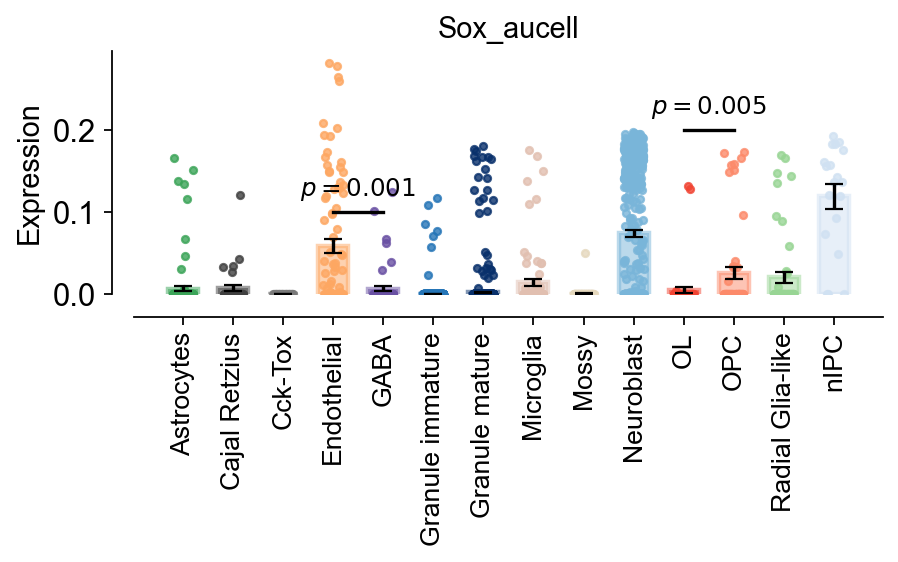

In [21]:
fig, ax = plt.subplots(figsize=(6,2))
ov.pl.bardotplot(adata,groupby='clusters',color='Sox_aucell',figsize=(6,2),
           ax=ax,
          ylabel='Expression',
           bar_kwargs={'alpha':0.5,'linewidth':2,'width':0.6,'capsize':4},
           scatter_kwargs={'alpha':0.8,'s':10,'marker':'o'})

ov.pl.add_palue(ax,line_x1=3,line_x2=4,line_y=0.1,
          text_y=0.02,
          text='$p={}$'.format(round(0.001,3)),
          fontsize=11,fontcolor='#000000',
             horizontalalignment='center',)

ov.pl.add_palue(
    ax,
    line_x1=10,#OL
    line_x2=11,#OPC
    line_y=0.2,#Expression
    text_y=0.02,
    text='$p={}$'.format(round(0.005,3)),
    fontsize=11,fontcolor='#000000',
    horizontalalignment='center',
)

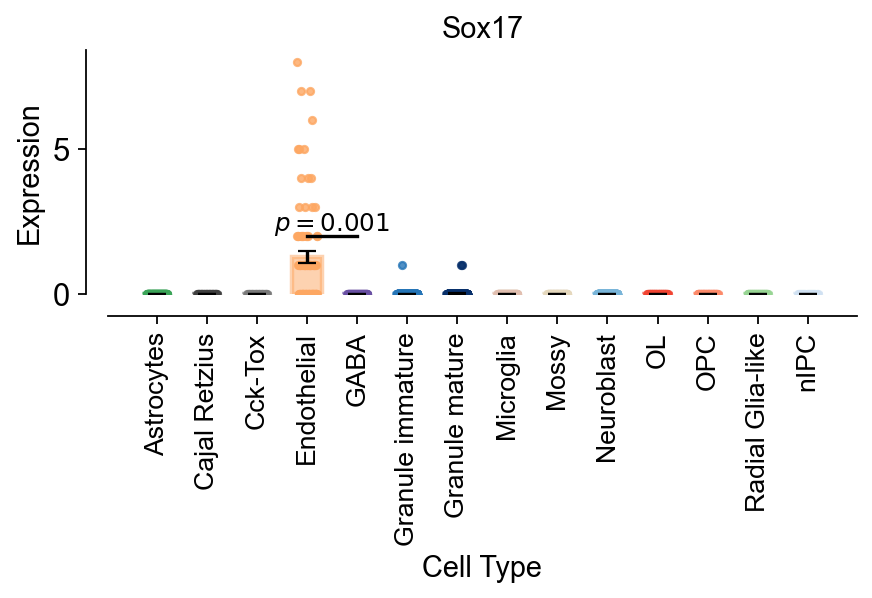

In [22]:
fig, ax = plt.subplots(figsize=(6,2))
ov.pl.bardotplot(adata,groupby='clusters',color='Sox17',figsize=(6,2),
           ax=ax,
          ylabel='Expression',xlabel='Cell Type',
           bar_kwargs={'alpha':0.5,'linewidth':2,'width':0.6,'capsize':4},
           scatter_kwargs={'alpha':0.8,'s':10,'marker':'o'})

ov.pl.add_palue(ax,line_x1=3,line_x2=4,line_y=2,
          text_y=0.2,
          text='$p={}$'.format(round(0.001,3)),
          fontsize=11,fontcolor='#000000',
             horizontalalignment='center',)

## Boxplot with jitter points 
A box plot, also known as a box-and-whisker plot, is a graphical representation used to display the distribution and summary statistics of a dataset. It provides a concise and visual way to understand the central tendency, spread, and potential outliers in the data.

**Function**: `ov.pl.single_group_boxplot`: 
 
- adata (AnnData object): The data object containing the information for plotting. 
- groupby (str): The variable used for grouping the data
- color (str): The variable used for coloring the data points.
- type_color_dict (dict): A dictionary mapping group categories to specific colors.  
- scatter_kwargs (dict): Additional keyword arguments for customizing the scatter plot.  
- ax (matplotlib.axes.Axes): A pre-existing axes object for plotting (optional).  (optional).(optional).
    

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 [Text(0, 0, 'Astrocytes'),
  Text(1, 0, 'Cajal Retzius'),
  Text(2, 0, 'Cck-Tox'),
  Text(3, 0, 'Endothelial'),
  Text(4, 0, 'GABA'),
  Text(5, 0, 'Granule immature'),
  Text(6, 0, 'Granule mature'),
  Text(7, 0, 'Microglia'),
  Text(8, 0, 'Mossy'),
  Text(9, 0, 'Neuroblast'),
  Text(10, 0, 'OL'),
  Text(11, 0, 'OPC'),
  Text(12, 0, 'Radial Glia-like'),
  Text(13, 0, 'nIPC')])

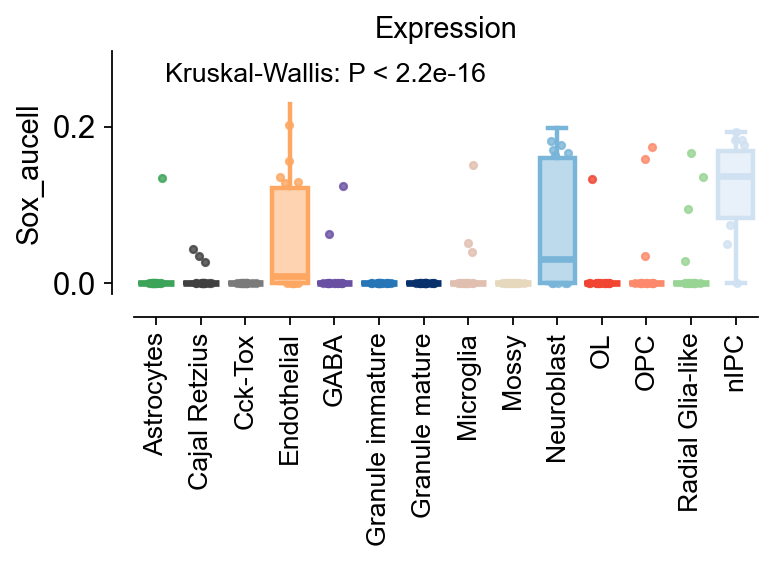

In [23]:
import pandas as pd
import seaborn as sns
#sns.set_style('white')

ov.pl.single_group_boxplot(adata,groupby='clusters',
             color='Sox_aucell',
             type_color_dict=dict(zip(pd.Categorical(adata.obs['clusters']).categories, adata.uns['clusters_colors'])),
             x_ticks_plot=True,
             figsize=(5,2),
             kruskal_test=True,
             ylabel='Sox_aucell',
             legend_plot=False,
             bbox_to_anchor=(1,1),
             title='Expression',
             scatter_kwargs={'alpha':0.8,'s':10,'marker':'o'},
             point_number=15,
             sort=False,
             save=False,
             )
plt.grid(False)
plt.xticks(rotation=90,fontsize=12)

## Dotplot

A complex heatmap, also known as a clustered heatmap, is a data visualization technique used to represent complex relationships and patterns in multivariate data. It combines several elements, including clustering, color mapping, and hierarchical organization, to provide a comprehensive view of data across multiple dimensions. 

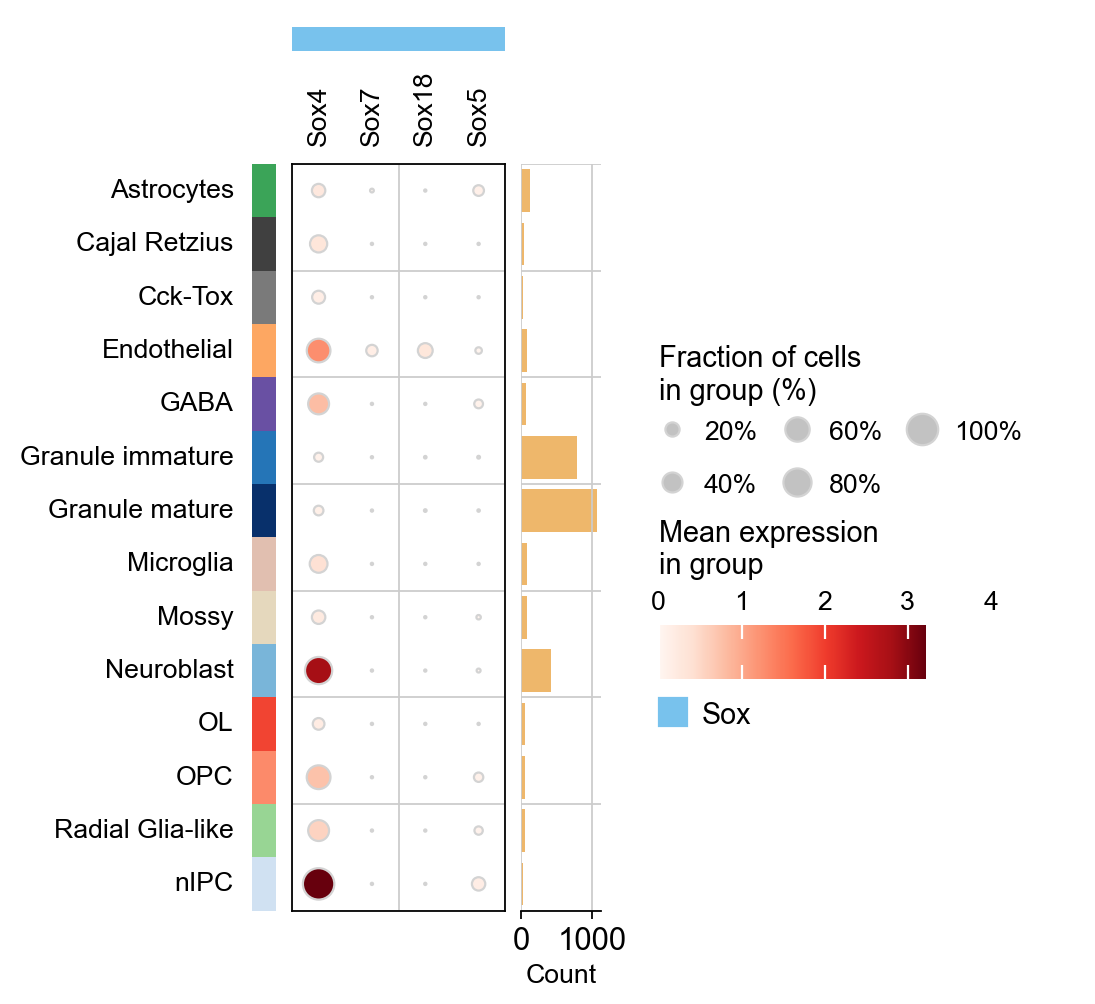

In [24]:
import pandas as pd
marker_genes_dict = {
    'Sox':['Sox4', 'Sox7', 'Sox18', 'Sox5'],
}
ov.pl.dotplot(
    adata,marker_genes_dict,
    groupby='clusters'
)


## Marker gene plot

In single-cell analysis, a marker gene heatmap is a powerful visualization tool that helps researchers to understand the expression patterns of specific marker genes across different cell populations. Here we provide `ov.pl.marker_heatmap` for visualizing the patterns of marker genes.

We first preprocess the data and define the dictionary of cell type and marker gene.
**Please ensure that each gene in the dictionary appears only once** (i.e. different cells cannot have the same marker gene, otherwise an error will be reported).

In [25]:
adata=ov.pp.preprocess(adata,mode='shiftlog|pearson',n_HVGs=2000,)

marker_genes_dict = {'Granule immature': ['Sepw1', 'Camk2b', 'Cnih2'],
 'Radial Glia-like': ['Dbi', 'Fabp7', 'Aldoc'],
 'Granule mature': ['Malat1', 'Rasl10a', 'Ppp3ca'],
 'Neuroblast': ['Igfbpl1', 'Tubb2b', 'Tubb5'],
 'Microglia': ['Lgmn', 'C1qa', 'C1qb'],
 'Cajal Retzius': ['Diablo', 'Ramp1', 'Stmn1'],
 'OPC': ['Olig1', 'C1ql1', 'Pllp'],
 'Cck-Tox': ['Tshz2', 'Cck', 'Nap1l5'],
 'GABA': ['Gad2', 'Gad1', 'Snhg11'],
 'Endothelial': ['Sparc', 'Myl12a', 'Itm2a'],
 'Astrocytes': ['Apoe',  'Atp1a2'],
 'OL': ['Plp1', 'Mog', 'Mag'],
 'Mossy': ['Arhgdig', 'Camk4'],
 'nIPC': ['Hmgn2', 'Ptma', 'H2afz']}

Begin robust gene identification
After filtration, 13264/13913 genes are kept.     Among 13264 genes, 13189 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell
The following highly-expressed genes are not considered during normalization factor computation:
['Hba-a1', 'Malat1', 'Ptgds', 'Hbb-bt']
    finished (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 0.6747586727142334 seconds.
End of size normalization: shiftlog and HVGs selection pearson


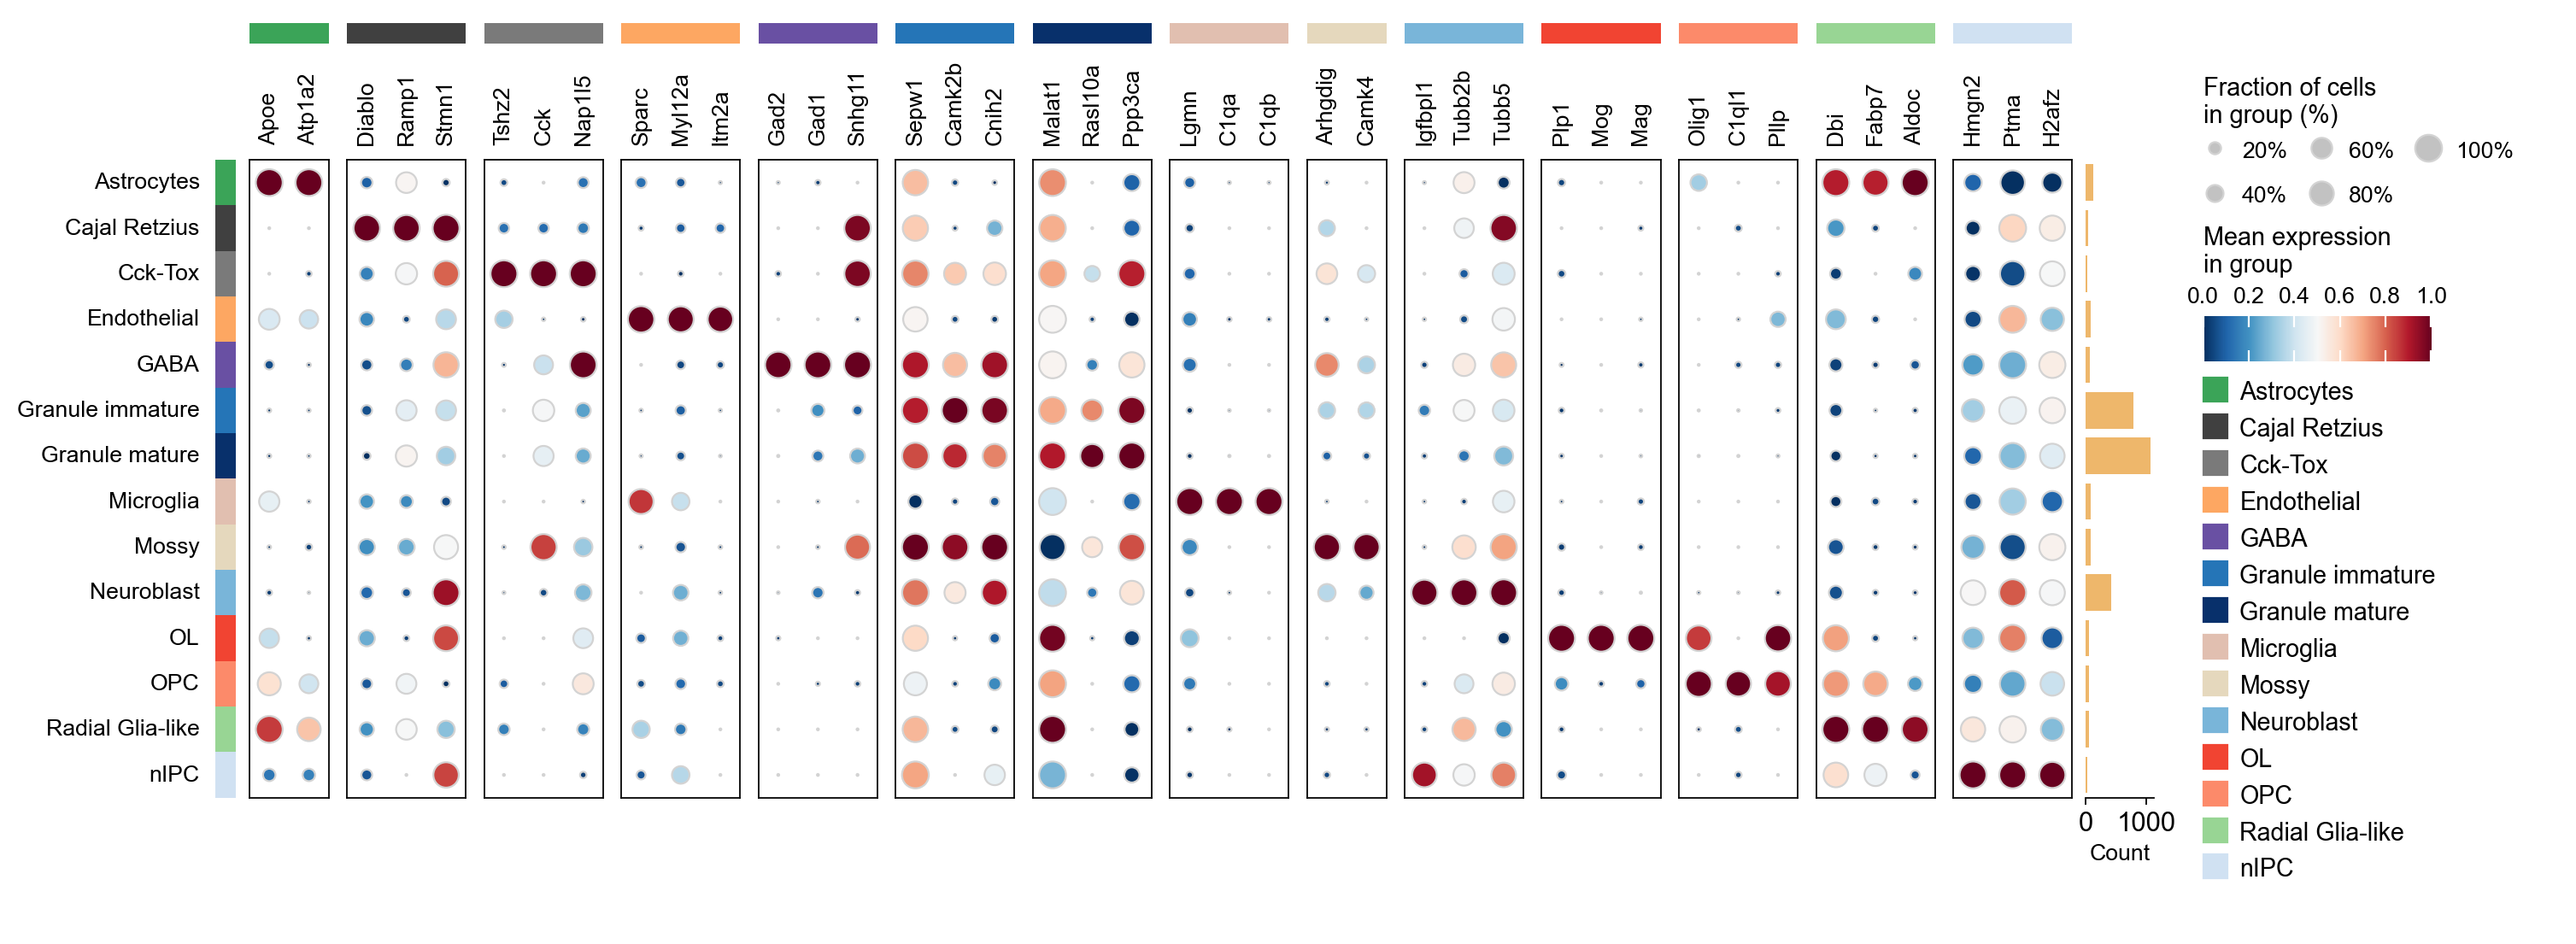

In [27]:
ov.pl.dotplot(
    adata,marker_genes_dict,
    groupby='clusters',cmap='RdBu_r',
    standard_scale='var'
)

## Beautiful UMAP

Here, we provide a combination of the above functions as an example to guide you in drawing a more beautiful UMAP.

In [46]:
color_dict=dict(zip(
    adata.obs['clusters'].cat.categories,
    adata.uns['clusters_colors']
))
color_dict

{'Astrocytes': '#3ba458',
 'Cajal Retzius': '#404040',
 'Cck-Tox': '#7a7a7a',
 'Endothelial': '#fda762',
 'GABA': '#6950a3',
 'Granule immature': '#2575b7',
 'Granule mature': '#08306b',
 'Microglia': '#e1bfb0',
 'Mossy': '#e5d8bd',
 'Neuroblast': '#79b5d9',
 'OL': '#f14432',
 'OPC': '#fc8a6a',
 'Radial Glia-like': '#98d594',
 'nIPC': '#d0e1f2'}

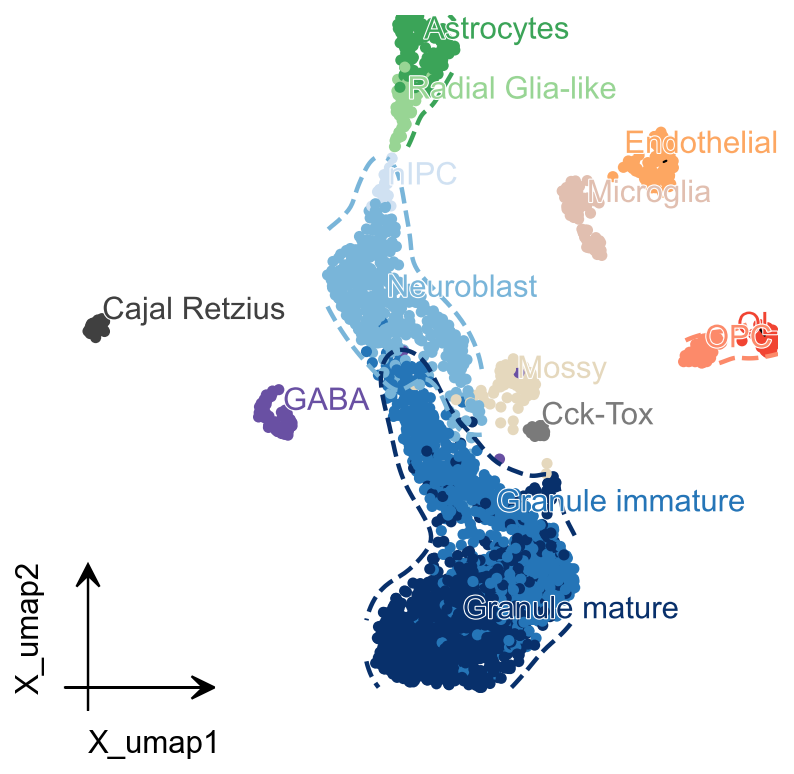

In [53]:
from matplotlib import patheffects
import matplotlib.pyplot as plt

# Create a figure and axis with a specified size
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the UMAP embedding with celltype coloring
ov.pl.embedding(
    adata,
    basis='X_umap',
    color=['clusters'],
    size=100,
    title='',
    show=False,
    legend_loc=None,
    add_outline=False,
    frameon='small',
    legend_fontoutline=2,
    ax=ax,
    arrow_scale = 10, 
    arrow_width = 0.005,
)

# Define celltype groups and their contour properties
contour_groups = [
    (['Granule immature','Granule mature'], '#08306b'),
    (['Radial Glia-like', 'Astrocytes', ], '#3ba458'),
    (['OL', 'OPC', ], '#fc8a6a'),
    (['nIPC', 'Neuroblast', ], '#79b5d9'),
]

# Plot contours for each group
for clusters, color in contour_groups:
    ov.pl.contour(
        ax=ax,
        adata=adata,
        groupby='clusters',
        clusters=clusters,
        basis='X_umap',
        contour_threshold=0.1,
        colors=color,
        linestyles='dashed',
        linewidths=2,
    )

ct_color=[]
for ct in color_dict:
    ct_color.append(([ct],color_dict[ct]))

all_celltypes=list(adata.obs['clusters'].unique())

# Adjust embedding annotations for each group
for exclude_clusters, text_color in ct_color:
    ov.pl.embedding_adjust(
        adata,
        groupby='clusters',
        exclude=set(all_celltypes)-set(exclude_clusters),
        basis='X_umap',
        ax=ax,
        adjust_kwargs=dict(arrowprops=dict(arrowstyle='-', color='black')),
        text_kwargs=dict(
            fontsize=14,
            weight='normal',
            color=text_color,
            path_effects=[patheffects.withStroke(linewidth=1, foreground='w')]
        )
    )